In [71]:
from langgraph.graph import StateGraph
from langchain_core.messages import AnyMessage,HumanMessage
from typing import Annotated
from typing_extensions import TypedDict
from dotenv import find_dotenv, load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

In [72]:
import os
load_dotenv(find_dotenv())

True

In [74]:
openai_api_key = os.environ["OPENAI_API_KEY"]

print("API Key Loaded:", os.environ.get("OPENAI_API_KEY"),"Got it")

API Key Loaded:  Got it


In [55]:
class AgentState(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(AgentState)

In [56]:
llm = init_chat_model("openai:gpt-3.5")

In [57]:
def chatbot(state: AgentState):
    return {"messages": [llm.invoke(state["messages"])]}



In [58]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

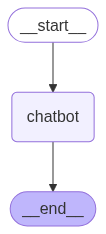

In [59]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [60]:
response = graph.invoke(AgentState(messages=[HumanMessage(content="Hello, What is Capital of India?")]))
response.messages[0].content

AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}